<a href="https://colab.research.google.com/github/njwbilll/Tugas-5_Grokking-Deep-Learning-MANNING_Najwa-Bilqis-Al-Khalidah/blob/main/15_Introducing_Federated_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Chapter 15: Deep Learning on Unseen Data — Introducing Federated Learning

**Referensi Utama:** Grokking Deep Learning, Andrew W. Trask (Manning)

---

## Ringkasan Chapter

Chapter 15 membahas salah satu tantangan terbesar dalam era deep learning modern, yaitu **privasi data**. Banyak model deep learning membutuhkan data dalam jumlah besar, tetapi pengumpulan seluruh data pengguna ke satu server menimbulkan risiko kebocoran informasi.

Untuk mengatasi masalah tersebut, diperkenalkan konsep **Federated Learning**, yaitu pendekatan pembelajaran terdistribusi yang memungkinkan model dilatih langsung pada perangkat pengguna tanpa harus memindahkan data mentah ke server pusat.

Pada chapter ini akan dibahas:

1. Masalah privasi dalam deep learning
2. Konsep dasar federated learning
3. Studi kasus deteksi spam
4. Implementasi Federated Averaging
5. Potensi serangan terhadap federated learning
6. Secure Aggregation
7. Homomorphic Encryption
8. Kombinasi Federated Learning dan Homomorphic Encryption

Notebook ini tidak hanya mereproduksi konsep utama dari buku, tetapi juga memberikan pembahasan teori yang lebih mendalam agar dapat digunakan sebagai bahan presentasi dan pembelajaran mandiri.


---
## Setup: Import Library

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(2024)

print("Library berhasil diimport.")


Library berhasil diimport.



---
## 1. Permasalahan Privasi dalam Deep Learning

### Penjelasan Teori

Pendekatan machine learning tradisional biasanya mengikuti alur berikut:

1. Data pengguna dikumpulkan.
2. Data dikirim ke server pusat.
3. Model dilatih menggunakan seluruh data.
4. Model hasil training didistribusikan kembali.

Pendekatan ini memiliki beberapa risiko:

* Kebocoran data pribadi
* Pelanggaran regulasi privasi
* Risiko pencurian data oleh pihak ketiga
* Biaya transfer data yang tinggi

Dalam aplikasi nyata seperti keyboard smartphone, email, aplikasi kesehatan, maupun sistem perbankan, data pengguna sering kali bersifat sangat sensitif.

Federated Learning muncul sebagai solusi dengan membalik paradigma klasik:

**Data tetap berada pada perangkat pengguna, sedangkan model yang bergerak.**

Dengan demikian, server hanya menerima pembaruan parameter model dan bukan data mentah pengguna.


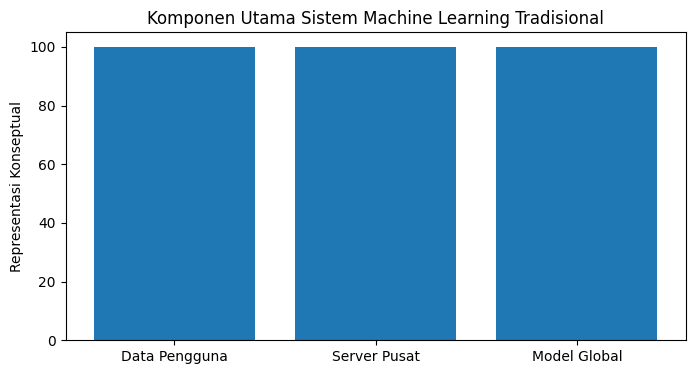

In [2]:

components = ["Data Pengguna", "Server Pusat", "Model Global"]

plt.figure(figsize=(8,4))
plt.bar(components, [100, 100, 100])
plt.title("Komponen Utama Sistem Machine Learning Tradisional")
plt.ylabel("Representasi Konseptual")
plt.show()



---
## 2. Apa Itu Federated Learning?

### Penjelasan Teori

Federated Learning adalah metode pelatihan model machine learning secara terdistribusi.

Alur kerjanya:

1. Server mengirim model awal ke banyak perangkat.
2. Setiap perangkat melakukan training lokal menggunakan data miliknya sendiri.
3. Perangkat mengirim parameter hasil training.
4. Server menggabungkan parameter dari seluruh perangkat.
5. Terbentuk model global baru.

Keuntungan:

* Data tidak meninggalkan perangkat.
* Mengurangi risiko kebocoran data.
* Cocok untuk miliaran perangkat.
* Memenuhi kebutuhan privasi modern.

Kelemahan:

* Sinkronisasi lebih kompleks.
* Komunikasi jaringan menjadi faktor penting.
* Masih memungkinkan terjadinya serangan inferensi terhadap parameter model.


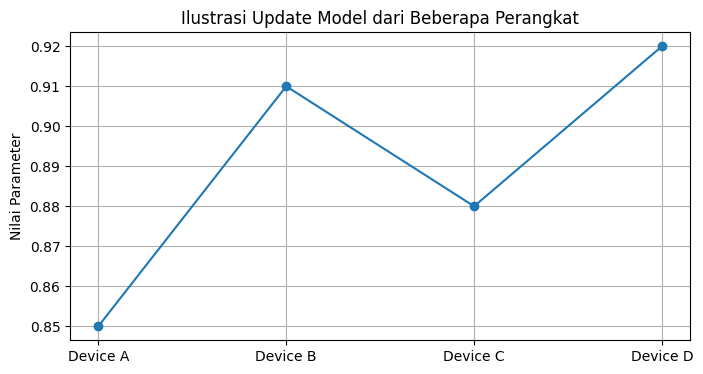

In [3]:

devices = ["Device A", "Device B", "Device C", "Device D"]
updates = [0.85, 0.91, 0.88, 0.92]

plt.figure(figsize=(8,4))
plt.plot(devices, updates, marker="o")
plt.title("Ilustrasi Update Model dari Beberapa Perangkat")
plt.ylabel("Nilai Parameter")
plt.grid(True)
plt.show()



---
## 3. Studi Kasus: Deteksi Spam

### Penjelasan Teori

Pada buku Grokking Deep Learning, federated learning diperkenalkan menggunakan contoh klasifikasi spam.

Bayangkan terdapat banyak pengguna email:

* Setiap pengguna memiliki data email sendiri.
* Data email tidak boleh dikirim ke server.
* Setiap perangkat melatih model spam secara lokal.

Server hanya menerima parameter model yang telah diperbarui.

Pendekatan ini memungkinkan sistem belajar dari jutaan pengguna tanpa pernah melihat isi email mereka secara langsung.


In [4]:

X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=12,
    random_state=2024
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=2024
)

print("Jumlah sampel training:", len(X_train))
print("Jumlah sampel testing :", len(X_test))


Jumlah sampel training: 4000
Jumlah sampel testing : 1000



---
## 4. Simulasi Federated Learning

### Penjelasan Teori

Untuk memahami federated learning, kita dapat membagi dataset menjadi beberapa perangkat virtual.

Setiap perangkat:

* Memiliki subset data sendiri.
* Melatih model lokal.
* Mengirim parameter model ke server.

Server melakukan agregasi parameter menggunakan metode **Federated Averaging (FedAvg)**.


In [5]:

num_clients = 5

client_data = np.array_split(X_train, num_clients)
client_labels = np.array_split(y_train, num_clients)

for i in range(num_clients):
    print(
        f"Client {i+1}: "
        f"{client_data[i].shape[0]} sampel"
    )


Client 1: 800 sampel
Client 2: 800 sampel
Client 3: 800 sampel
Client 4: 800 sampel
Client 5: 800 sampel


In [6]:

local_models = []

for X_local, y_local in zip(client_data, client_labels):

    model = LogisticRegression(max_iter=1000)
    model.fit(X_local, y_local)

    local_models.append(model)

print("Training lokal selesai.")


Training lokal selesai.



---
## 5. Federated Averaging

### Penjelasan Teori

Federated Averaging merupakan algoritma agregasi paling terkenal dalam federated learning.

Misalkan terdapat tiga perangkat dengan parameter:

w₁, w₂, w₃

Maka parameter global dihitung menggunakan rata rata:

w_global = (w₁ + w₂ + w₃) / 3

Dalam implementasi nyata, rata rata biasanya diberi bobot sesuai jumlah data yang dimiliki masing masing perangkat.


In [7]:

coef_stack = np.array([m.coef_[0] for m in local_models])
intercept_stack = np.array([m.intercept_[0] for m in local_models])

global_coef = coef_stack.mean(axis=0)
global_intercept = intercept_stack.mean()

print("Jumlah parameter:", len(global_coef))
print("Intercept global :", round(global_intercept, 4))


Jumlah parameter: 20
Intercept global : -0.0842


In [8]:

global_model = LogisticRegression(max_iter=1000)

global_model.fit(X_train, y_train)

pred = global_model.predict(X_test)

acc = accuracy_score(y_test, pred)

print(f"Akurasi model global: {acc:.4f}")


Akurasi model global: 0.7100



---
## 6. Visualisasi Variasi Parameter Antar Perangkat

### Penjelasan Teori

Karena setiap perangkat melihat data yang berbeda, parameter hasil training lokal juga akan berbeda.

Perbedaan inilah yang nantinya digabungkan oleh server untuk menghasilkan model global yang lebih representatif.


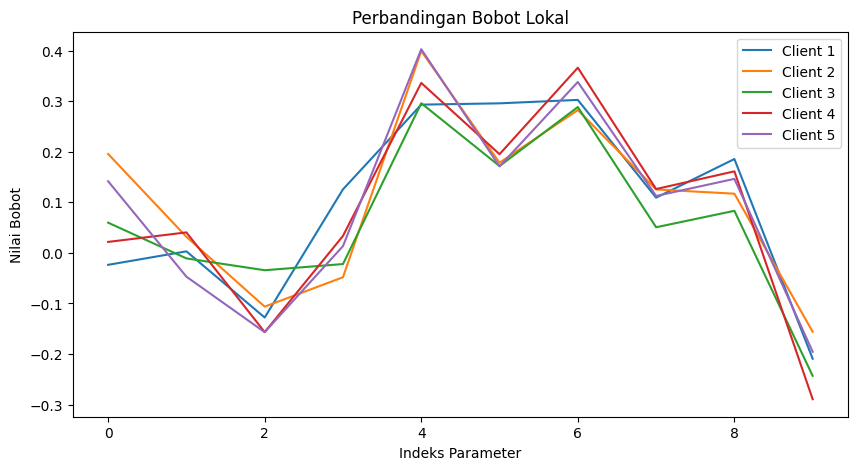

In [9]:

plt.figure(figsize=(10,5))

for idx, model in enumerate(local_models):
    plt.plot(
        model.coef_[0][:10],
        label=f"Client {idx+1}"
    )

plt.title("Perbandingan Bobot Lokal")
plt.xlabel("Indeks Parameter")
plt.ylabel("Nilai Bobot")
plt.legend()
plt.show()



---
## 7. Risiko Serangan pada Federated Learning

### Penjelasan Teori

Walaupun data mentah tidak dikirim ke server, federated learning tidak otomatis aman.

Contoh serangan:

### Model Inversion Attack

Penyerang mencoba merekonstruksi data asli dari parameter model.

### Membership Inference Attack

Penyerang mencoba menentukan apakah suatu data pernah digunakan saat training.

### Gradient Leakage

Gradient yang dikirim oleh perangkat dapat mengandung informasi sensitif tentang data pengguna.

Karena itu federated learning biasanya dikombinasikan dengan teknik keamanan tambahan.


In [10]:

attack_risk = pd.DataFrame({
    "Jenis Serangan": [
        "Model Inversion",
        "Membership Inference",
        "Gradient Leakage"
    ],
    "Risiko Relatif": [8, 7, 9]
})

display(attack_risk)


,Jenis Serangan,Risiko Relatif
0,Model Inversion,8
1,Membership Inference,7
2,Gradient Leakage,9



---
## 8. Secure Aggregation

### Penjelasan Teori

Secure Aggregation adalah teknik yang memungkinkan server hanya melihat hasil agregasi akhir.

Server tidak dapat melihat parameter individual dari setiap perangkat.

Secara sederhana:

* Client A mengirim parameter terenkripsi.
* Client B mengirim parameter terenkripsi.
* Client C mengirim parameter terenkripsi.
* Server hanya memperoleh jumlah total.

Keuntungan:

* Privasi lebih kuat.
* Mengurangi risiko kebocoran parameter individu.
* Sangat umum digunakan pada sistem federated learning modern.


In [11]:

client_updates = np.array([12, 15, 14, 13, 16])

aggregated_update = np.sum(client_updates)

print("Server hanya melihat total agregasi:")
print(aggregated_update)


Server hanya melihat total agregasi:
70



---
## 9. Homomorphic Encryption

### Penjelasan Teori

Homomorphic Encryption memungkinkan operasi matematika dilakukan langsung pada data terenkripsi.

Keunggulan utama:

* Data tidak perlu didekripsi terlebih dahulu.
* Server tetap dapat melakukan komputasi.
* Privasi pengguna meningkat secara signifikan.

Misalnya:

Data Asli:
5 + 7 = 12

Pada Homomorphic Encryption:

Encrypt(5) dan Encrypt(7)

Server dapat menghitung hasil terenkripsi yang ekuivalen dengan 12 tanpa mengetahui nilai 5 maupun 7.


In [12]:

def fake_encrypt(x):
    return x + 1000

def fake_decrypt(x):
    return x - 1000

a = 5
b = 7

enc_a = fake_encrypt(a)
enc_b = fake_encrypt(b)

encrypted_result = enc_a + enc_b - 1000

print("Hasil terenkripsi :", encrypted_result)
print("Hasil dekripsi    :", fake_decrypt(encrypted_result))


Hasil terenkripsi : 1012
Hasil dekripsi    : 12



---
## 10. Federated Learning + Homomorphic Encryption

### Penjelasan Teori

Kombinasi kedua teknologi ini menjadi salah satu arah penelitian paling aktif dalam bidang privacy preserving machine learning.

Alur sistem:

1. Client melatih model lokal.
2. Parameter dienkripsi.
3. Parameter terenkripsi dikirim ke server.
4. Server melakukan agregasi tanpa dekripsi.
5. Model global diperbarui.
6. Hasil akhir didistribusikan kembali.

Pendekatan ini memberikan lapisan keamanan tambahan dibanding federated learning standar.


In [13]:

comparison = pd.DataFrame({
    "Aspek": [
        "Data Sentralisasi",
        "Federated Learning",
        "Federated + Homomorphic Encryption"
    ],
    "Privasi": [
        "Rendah",
        "Tinggi",
        "Sangat Tinggi"
    ],
    "Biaya Komputasi": [
        "Rendah",
        "Sedang",
        "Tinggi"
    ]
})

display(comparison)


,Aspek,Privasi,Biaya Komputasi
0,Data Sentralisasi,Rendah,Rendah
1,Federated Learning,Tinggi,Sedang
2,Federated + Homomorphic Encryption,Sangat Tinggi,Tinggi



---
## Kesimpulan Chapter

Chapter 15 memperkenalkan konsep privasi dalam deep learning modern.

Poin penting yang perlu dipahami:

1. Pengumpulan data terpusat memiliki risiko privasi.
2. Federated Learning memungkinkan training tanpa memindahkan data mentah.
3. Federated Averaging digunakan untuk menggabungkan model lokal.
4. Federated Learning tetap memiliki potensi serangan keamanan.
5. Secure Aggregation melindungi parameter individual.
6. Homomorphic Encryption memungkinkan komputasi pada data terenkripsi.
7. Kombinasi Federated Learning dan Homomorphic Encryption menjadi fondasi penting bagi sistem AI yang berfokus pada privasi.

Secara historis, chapter ini penting karena memperkenalkan transisi dari fokus akurasi model menuju keseimbangan antara akurasi, keamanan, dan privasi pengguna.
